In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

## 📊 Exploratory Data Analysis

Before building any model, we explore the data to understand feature distributions
and relationships. The dataset has 20,640 California housing records with 8 features.

In [54]:
# Load dataset
data = fetch_california_housing()

# Convert to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target

# Explore
print(df.shape)
print(df.head())
print(df.describe())

(20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%  

### Feature Correlation Analysis

We check which features correlate most strongly with Price.
MedInc (median income) is expected to dominate since wealthier 
neighborhoods have higher property values.

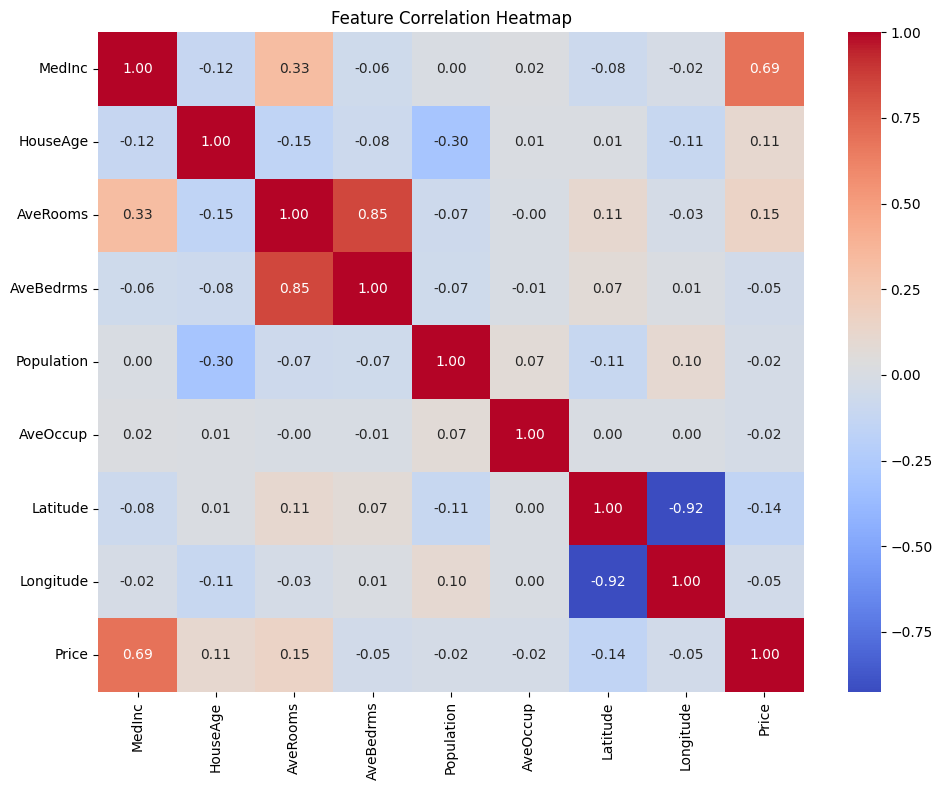

In [55]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Price']


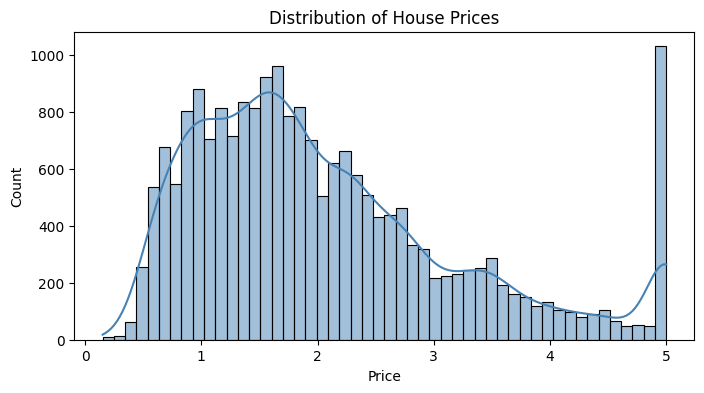

In [56]:
plt.figure(figsize=(8, 4))
print(list(df.columns))
sns.histplot(df["Price"], bins=50, kde=True, color="steelblue")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.savefig("target_distribution.png")
plt.show()

In [57]:
# Check for missing values
print(df.isnull().sum())

# Check for duplicates
print("Duplicates:", df.duplicated().sum())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64
Duplicates: 0


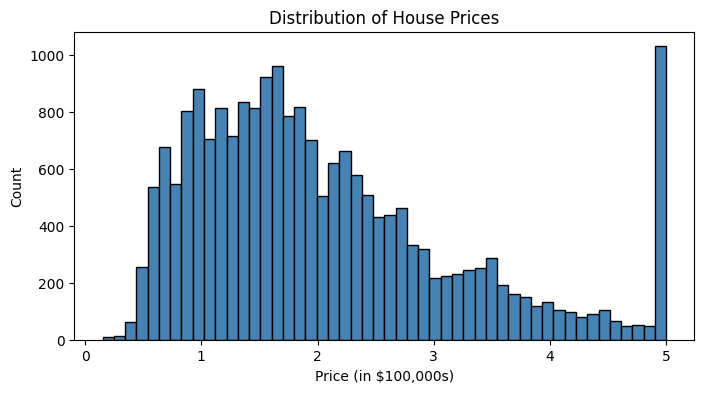

In [58]:
# See how Price is distributed
plt.figure(figsize=(8,4))
plt.hist(df['Price'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of House Prices')
plt.xlabel('Price (in $100,000s)')
plt.ylabel('Count')
plt.show()

In [59]:
# Top correlated features
corr = df.corr()["Price"].sort_values(ascending=False)
print(corr)

Price         1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: Price, dtype: float64


In [60]:
# Split features and target
X = df.drop('Price', axis=1)
y = df['Price']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 16512
Testing samples: 4128


## 🤖 Model Training & Comparison

We compare three regression approaches:
- **Linear Regression** — baseline, no regularization
- **Ridge** — L2 penalty, shrinks coefficients but keeps all features  
- **Lasso** — L1 penalty, can zero out features entirely

Goal: see if regularization improves on the baseline R².

In [61]:
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Model trained successfully!
Coefficients: [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
Intercept: -37.023277706064235


In [62]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred)**0.5)


R2 Score: 0.5757877060324508
MSE: 0.5558915986952443
RMSE: 0.7455813830127763


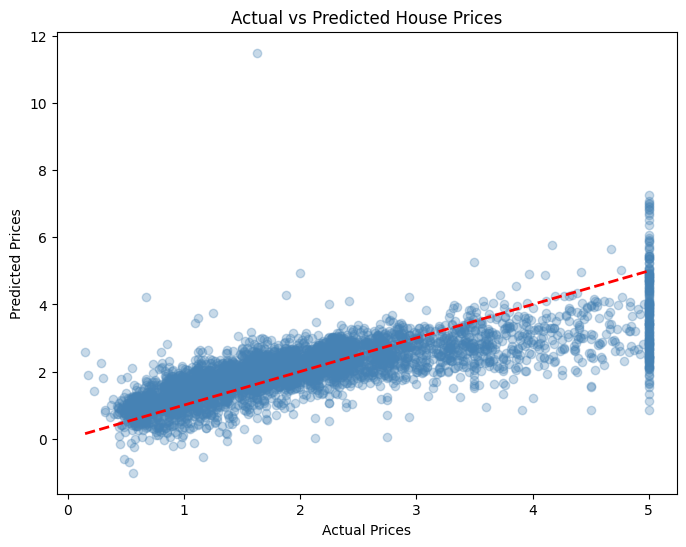

In [63]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.show()

In [64]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=1)": Ridge(alpha=1.0),
    "Ridge (alpha=10)": Ridge(alpha=10.0),
    "Lasso (alpha=0.1)": Lasso(alpha=0.1),
    "Lasso (alpha=1)": Lasso(alpha=1.0),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        "R2": round(r2_score(y_test, preds), 4),
        "MAE": round(mean_absolute_error(y_test, preds), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, preds)), 4)
    }

import pandas as pd
results_df = pd.DataFrame(results).T
print(results_df)

                       R2     MAE    RMSE
Linear Regression  0.5758  0.5332  0.7456
Ridge (alpha=1)    0.5759  0.5332  0.7455
Ridge (alpha=10)   0.5764  0.5332  0.7450
Lasso (alpha=0.1)  0.5318  0.5816  0.7833
Lasso (alpha=1)    0.2842  0.7616  0.9685


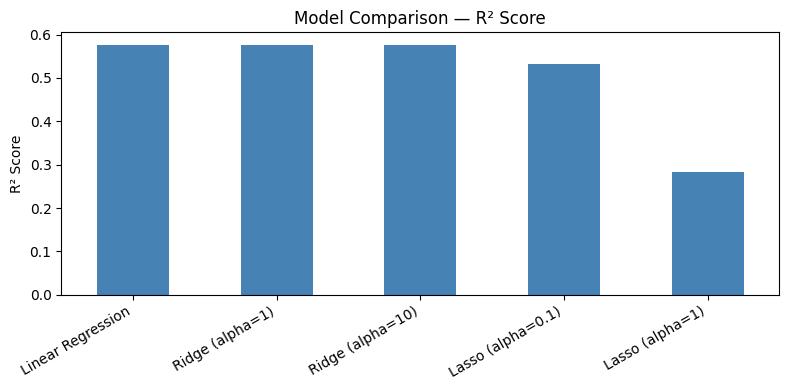

In [65]:
import matplotlib.pyplot as plt

results_df["R2"].plot(kind="bar", color="steelblue", figsize=(8,4))
plt.title("Model Comparison — R² Score")
plt.ylabel("R² Score")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()

## 🔮 Interactive Prediction

Modify the sample values below to predict house prices for any input.
Price is in units of $100,000 (e.g. output of 2.6 = $260,000).

In [66]:
# Interactive Prediction (use your best model from above)
best_model = Ridge(alpha=1.0)
best_model.fit(X_train, y_train)

# Change these values to predict for a sample house
sample = {
    "MedInc": 5.0,
    "HouseAge": 20.0,
    "AveRooms": 6.0,
    "AveBedrms": 1.0,
    "Population": 300.0,
    "AveOccup": 2.5,
    "Latitude": 37.5,
    "Longitude": -122.0
}

import pandas as pd
sample_df = pd.DataFrame([sample])
predicted_price = best_model.predict(sample_df)[0]
print(f"Predicted House Price: ${predicted_price * 100000:,.0f}")

Predicted House Price: $261,861
